# StyleGAN (cats & dogs) — FID & ResNet50 vs kimg

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DPI = 300
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 17,
    "legend.fontsize": 13,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "figure.titlesize": 20,
    "figure.dpi": DPI,
    "savefig.dpi": DPI,
})

ROOT = Path(".").resolve()
OUTPUTS = ROOT / "outputs_cats_dogs"


def plot_lines_vs_kimg(data, y_col, ylabel, title):
    fig, ax = plt.subplots(figsize=(12, 7), dpi=DPI)
    psi_values = sorted(data["truncation_psi"].unique())
    cmap = plt.cm.plasma
    colors = [cmap(i / max(len(psi_values) - 1, 1)) for i in range(len(psi_values))]
    for psi, color in zip(psi_values, colors):
        sub = data[data["truncation_psi"] == psi].sort_values("kimg")
        ax.plot(
            sub["kimg"], sub[y_col],
            marker="o", linewidth=2.2, markersize=7,
            color=color, label=f"psi = {psi}",
        )
    ax.set_xlabel("kimg")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(title="truncation psi", loc="best", ncol=2, framealpha=0.95)
    plt.tight_layout()
    plt.show()

## FID vs kimg (all truncation psi)

                     checkpoint  kimg  truncation_psi       FID
0   network-snapshot-000000.pkl     0            0.10  343.2988
6   network-snapshot-000200.pkl   200            0.10  289.7649
12  network-snapshot-000400.pkl   400            0.10  189.2025
18  network-snapshot-000600.pkl   600            0.10  176.7433
24  network-snapshot-000800.pkl   800            0.10  123.8181
30  network-snapshot-001000.pkl  1000            0.10  137.5925
1   network-snapshot-000000.pkl     0            0.80  286.8509
7   network-snapshot-000200.pkl   200            0.80  218.5295
13  network-snapshot-000400.pkl   400            0.80  135.8717
19  network-snapshot-000600.pkl   600            0.80   66.3325
25  network-snapshot-000800.pkl   800            0.80   45.1697
31  network-snapshot-001000.pkl  1000            0.80   38.7262
2   network-snapshot-000000.pkl     0            0.85  286.1733
8   network-snapshot-000200.pkl   200            0.85  215.8076
14  network-snapshot-000400.pkl   400   

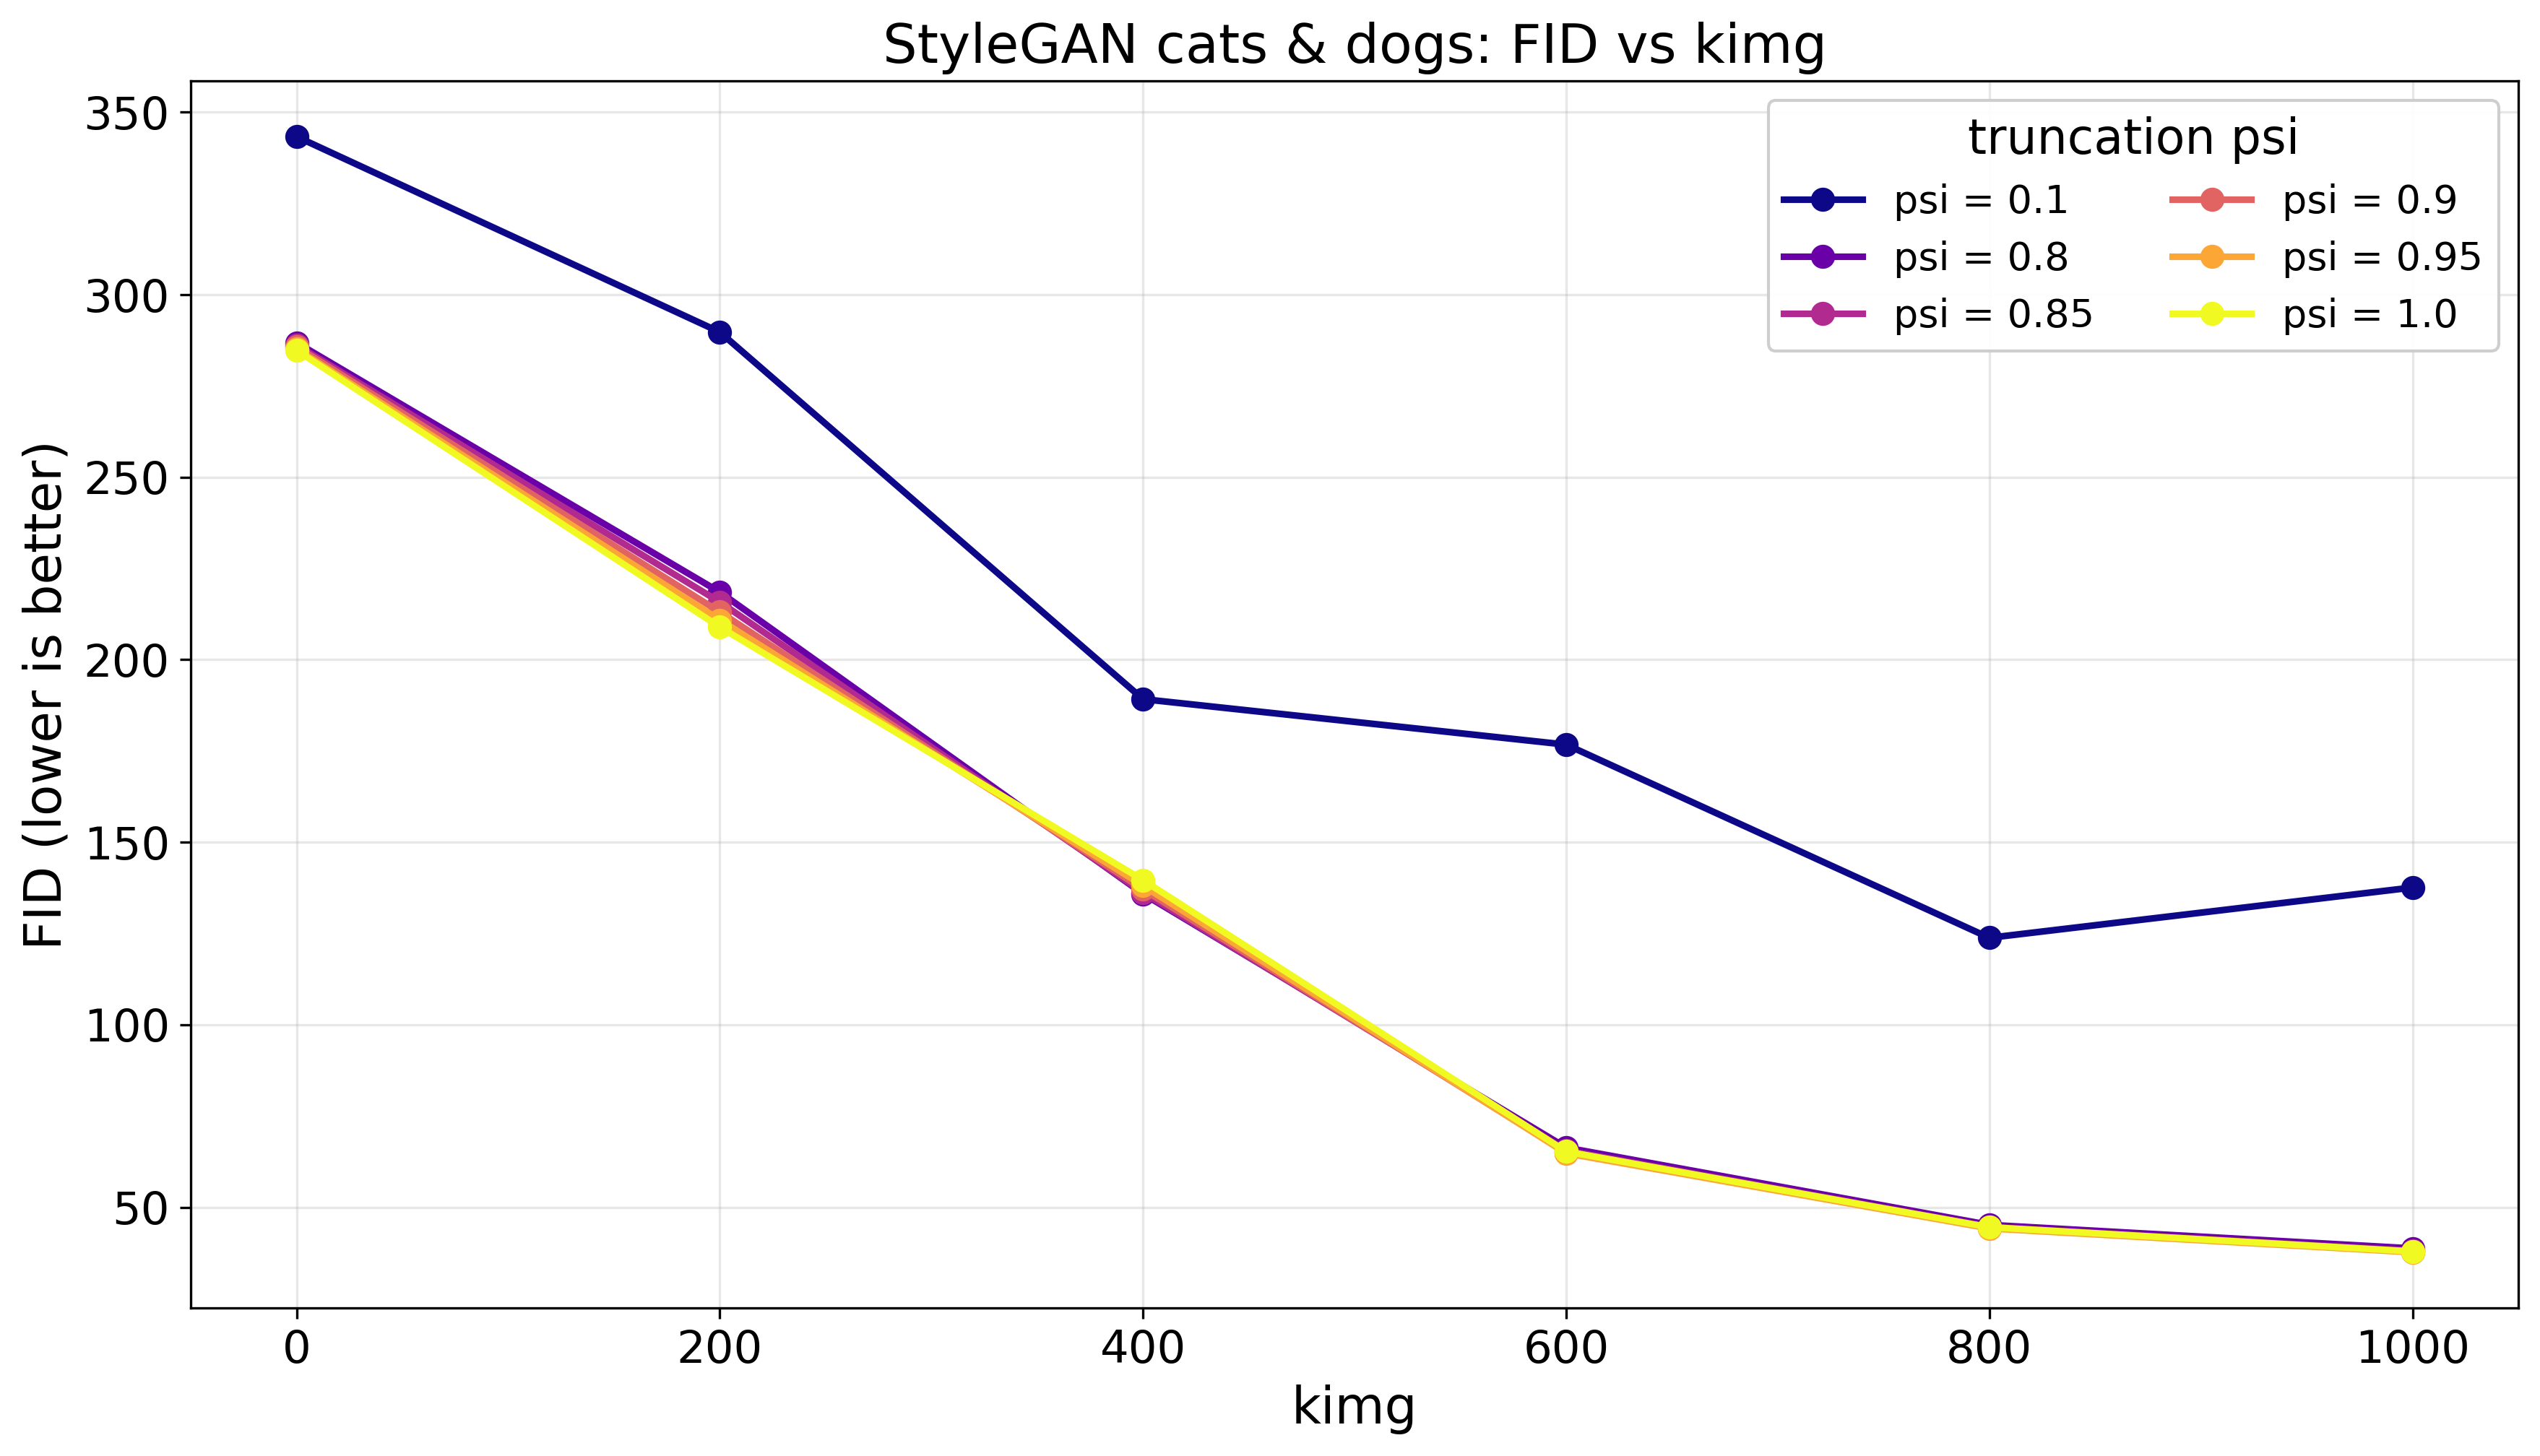

In [2]:
fid_df = pd.read_csv(OUTPUTS / "stylegan_fid_results.csv")
fid_df = fid_df.sort_values(["truncation_psi", "kimg"])
print(fid_df)

plot_lines_vs_kimg(
    fid_df,
    "FID",
    "FID (lower is better)",
    "StyleGAN cats & dogs: FID vs kimg",
)

## ResNet50 cat & dog score vs kimg (one plot)

Solid = cat breeds (281-285), dashed = dog breeds (151-268); color = truncation psi.

CSV: `stylegan_species_score_results_psi*.csv` from `evaluate.py`.

In [3]:
species_files = sorted(OUTPUTS.glob("stylegan_species_score_results_psi*.csv"))
if not species_files:
    raise FileNotFoundError(f"No ResNet50 CSV in {OUTPUTS}")

parts = []
for path in species_files:
    tag = path.stem.replace("stylegan_species_score_results_psi", "")
    psi_from_name = float(tag.replace("p", "."))
    chunk = pd.read_csv(path)
    if "truncation_psi" not in chunk.columns:
        chunk["truncation_psi"] = psi_from_name
    parts.append(chunk)

species_df = pd.concat(parts, ignore_index=True).sort_values(["truncation_psi", "kimg"])
print(species_df)
print("\npsi values:", sorted(species_df["truncation_psi"].unique()))

                    checkpoint  kimg  truncation_psi  cat_score  \
0  network-snapshot-000000.pkl     0             0.9   0.000174   
1  network-snapshot-000200.pkl   200             0.9   0.000768   
2  network-snapshot-000400.pkl   400             0.9   0.072876   
3  network-snapshot-000600.pkl   600             0.9   0.267220   
4  network-snapshot-000800.pkl   800             0.9   0.352005   
5  network-snapshot-001000.pkl  1000             0.9   0.358462   

   cat_score_std  dog_score  dog_score_std  
0       0.000167   0.004188       0.003661  
1       0.003086   0.105695       0.243549  
2       0.211112   0.301853       0.387095  
3       0.403106   0.394981       0.447749  
4       0.432564   0.410522       0.453115  
5       0.434398   0.461362       0.468051  

psi values: [np.float64(0.9)]


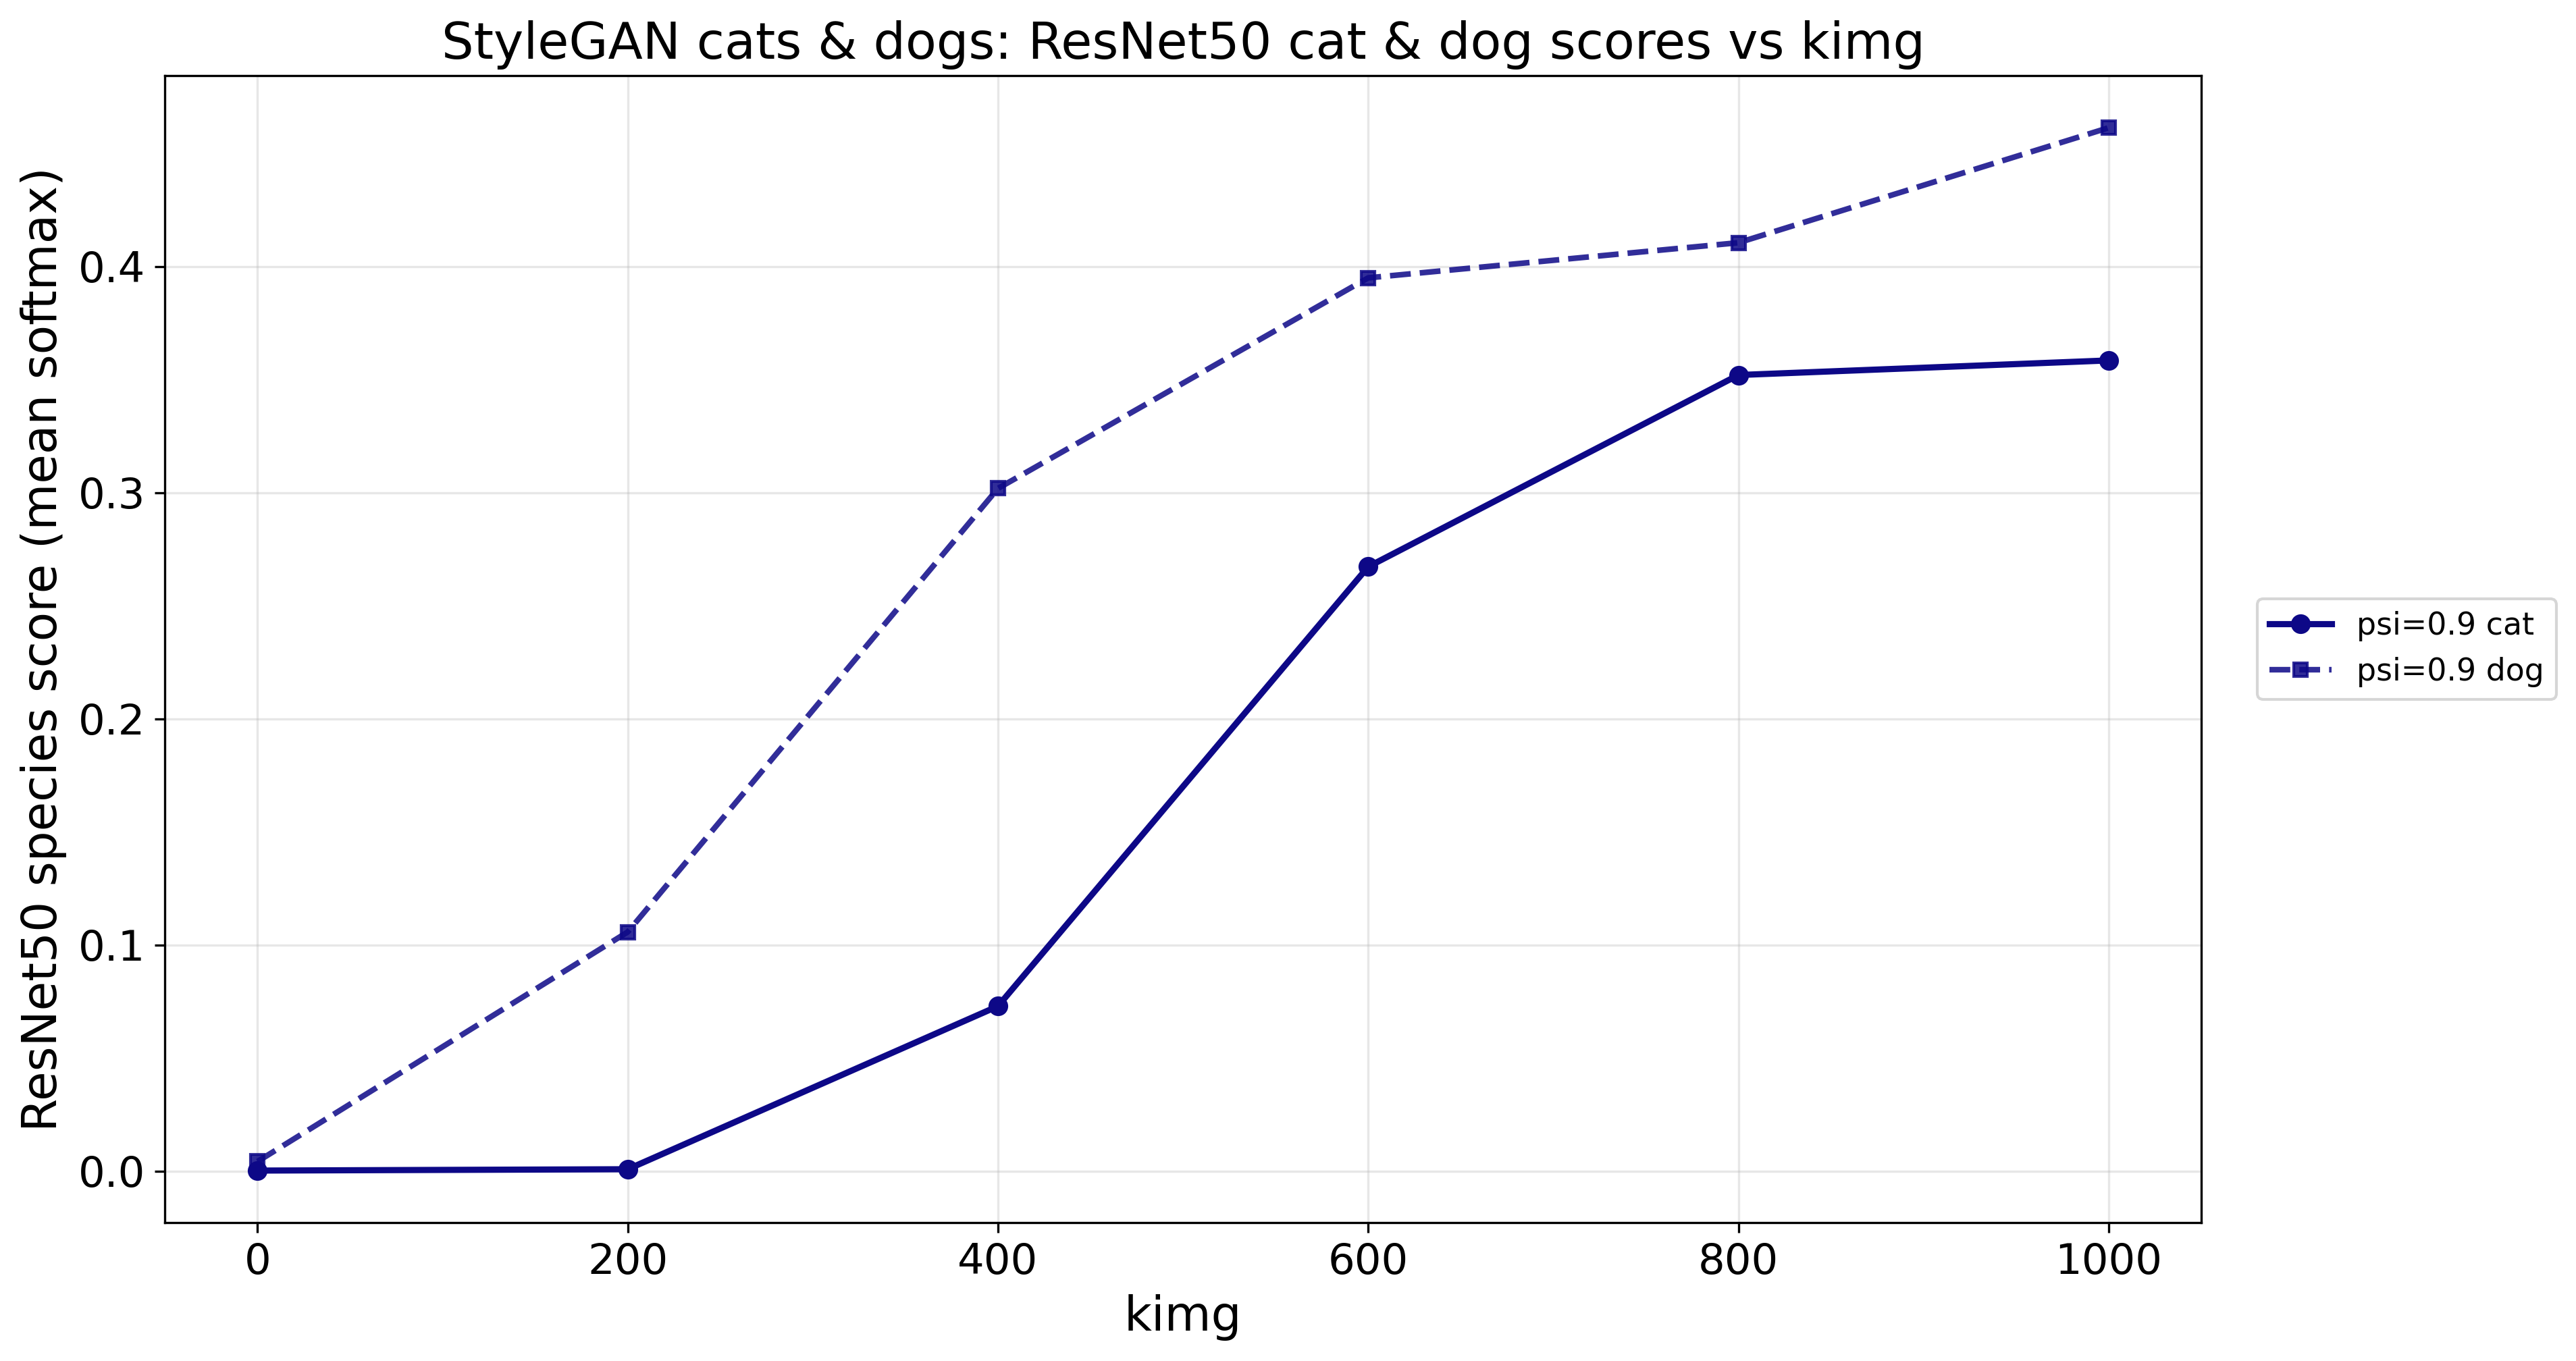

In [4]:
fig, ax = plt.subplots(figsize=(13, 7), dpi=DPI)

psi_values = sorted(species_df["truncation_psi"].unique())
cmap = plt.cm.plasma
colors = [cmap(i / max(len(psi_values) - 1, 1)) for i in range(len(psi_values))]

for psi, color in zip(psi_values, colors):
    sub = species_df[species_df["truncation_psi"] == psi].sort_values("kimg")
    ax.plot(
        sub["kimg"], sub["cat_score"],
        marker="o", linewidth=2.2, markersize=6,
        color=color, linestyle="-",
        label=f"psi={psi} cat",
    )
    ax.plot(
        sub["kimg"], sub["dog_score"],
        marker="s", linewidth=2.0, markersize=5,
        color=color, linestyle="--", alpha=0.85,
        label=f"psi={psi} dog",
    )

ax.set_xlabel("kimg")
ax.set_ylabel("ResNet50 species score (mean softmax)")
ax.set_title("StyleGAN cats & dogs: ResNet50 cat & dog scores vs kimg")
ax.grid(True, alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=11, ncol=1)
plt.tight_layout()
plt.show()